In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from sklearn.metrics import classification_report


In [ ]:
train_dir = "/content/drive/MyDrive/AI_ML/workshop5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI_ML/workshop5/FruitinAmazon/test"

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


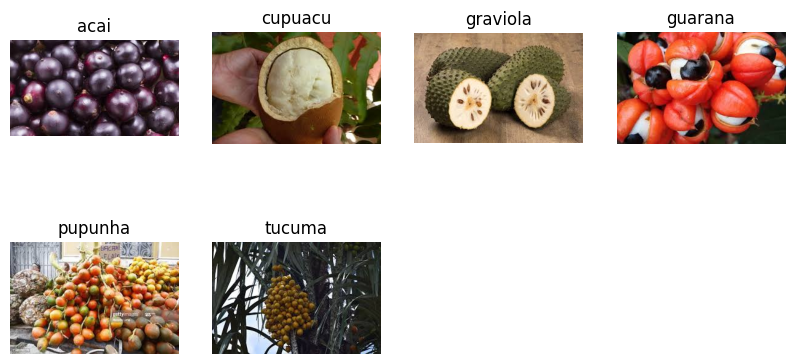

In [ ]:
class_names = os.listdir(train_dir)
print("Classes:", class_names)

plt.figure(figsize=(10, 5))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    img_name = np.random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, len(class_names)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
corrupted = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
num_classes = len(class_names)

model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2), strides=2),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.2372 - loss: 2.4579
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - accuracy: 0.2222 - loss: 2.4572 - val_accuracy: 0.0000e+00 - val_loss: 1.9209
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.2403 - loss: 1.7371
Epoch 2: val_accuracy improved from 0.00000 to 0.16667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.2639 - loss: 1.6966 - val_accuracy: 0.1667 - val_loss: 1.6142
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.3521 - loss: 1.4860
Epoch 3: val_accuracy improved from 0.16667 to 0.33333, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.3750 - loss: 1.4147 - val_accuracy: 0.3333 - val_loss: 1.5219
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5649 - loss: 1.0489
Epoch 4: val_accuracy improved from 0.33333 to 0.38889, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.5694 - loss: 1.0735 - val_accuracy: 0.3889 - val_loss: 1.4337
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8146 - loss: 0.8329
Epoch 5: val_accuracy improved from 0.38889 to 0.66667, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 659ms/step - accuracy: 0.7917 - loss: 0.8138 - val_accuracy: 0.6667 - val_loss: 0.6998
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8635 - loss: 0.5214
Epoch 6: val_accuracy improved from 0.66667 to 0.77778, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - accuracy: 0.8750 - loss: 0.5025 - val_accuracy: 0.7778 - val_loss: 0.9926
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8781 - loss: 0.3897
Epoch 7: val_accuracy improved from 0.77778 to 0.88889, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 0.8333 - loss: 0.4193 - val_accuracy: 0.8889 - val_loss: 0.2796
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9153 - loss: 0.2954
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - accuracy: 0.8889 - loss: 0.3329 - val_accuracy: 0.7778 - val_loss: 0.4449
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9844 - loss: 0.1247
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.9583 - loss: 0.1897 - val_accuracy: 0.8333 - val_loss: 0.4801
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9899 - loss: 0.0656
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - accuracy: 0.9861 - loss: 0.0794 - val_accuracy: 0.8333 - val_loss: 0.5729
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9635 - loss: 0.

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,639,668 (48.22 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,426,446 (32.14 MB)

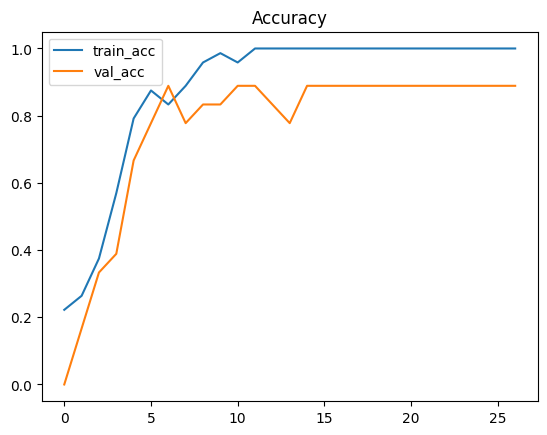

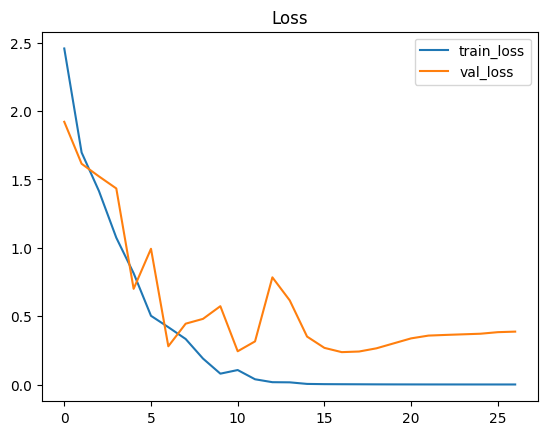

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8889 - loss: 0.2368 
Validation Accuracy: 0.8888888955116272


In [ ]:
model.save("cnn_model.h5")

loaded_model = keras.models.load_model("cnn_model.h5")

loaded_model.evaluate(val_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8889 - loss: 0.2368 


[0.23684747517108917, 0.8888888955116272]

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Get unique labels actually present in y_true
labels_present = np.unique(y_true)

# Create target_names for only the labels present
# Ensure class_names is accessible and correctly ordered if using direct indexing
# Assuming class_names is ordered according to the integer labels generated by image_dataset_from_directory
target_names_for_report = [class_names[i] for i in labels_present]

print(classification_report(
    y_true,
    y_pred,
    labels=labels_present,
    target_names=target_names_for_report
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
              precision    recall  f1-score   support

     pupunha       0.75      1.00      0.86         3
      tucuma       1.00      0.87      0.93        15

   micro avg       0.94      0.89      0.91        18
   macro avg       0.88      0.93      0.89        18
weighted avg       0.96      0.89      0.92        18



In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

# Re-extract class names and update num_classes
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

# Normalize validation dataset
val_ds = val_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))

# Define early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print(f"Classes: {class_names}")
print("Validation dataset and callbacks ready.")

Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Validation dataset and callbacks ready.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

# Centralized Configuration
train_dir = "/content/drive/MyDrive/AI_ML/workshop5/FruitinAmazon/train"
img_height, img_width = 128, 128
batch_size = 16
validation_split = 0.2

# Single source of truth for Class Names
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

# Unified Data Loading
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), batch_size=batch_size,
    shuffle=True, validation_split=validation_split, subset='training', seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), batch_size=batch_size,
    shuffle=False, validation_split=validation_split, subset='validation', seed=123
)

# Normalization
rescale = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"Setup complete. Classes: {class_names}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Setup complete. Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
model = keras.Sequential([
layers.Input(shape=(128, 128, 3)),
*data_augmentation_layers, # Include augmentation before the model layers
layers.Conv2D(32, (3,3), activation="relu"),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(10, activation="softmax")
])

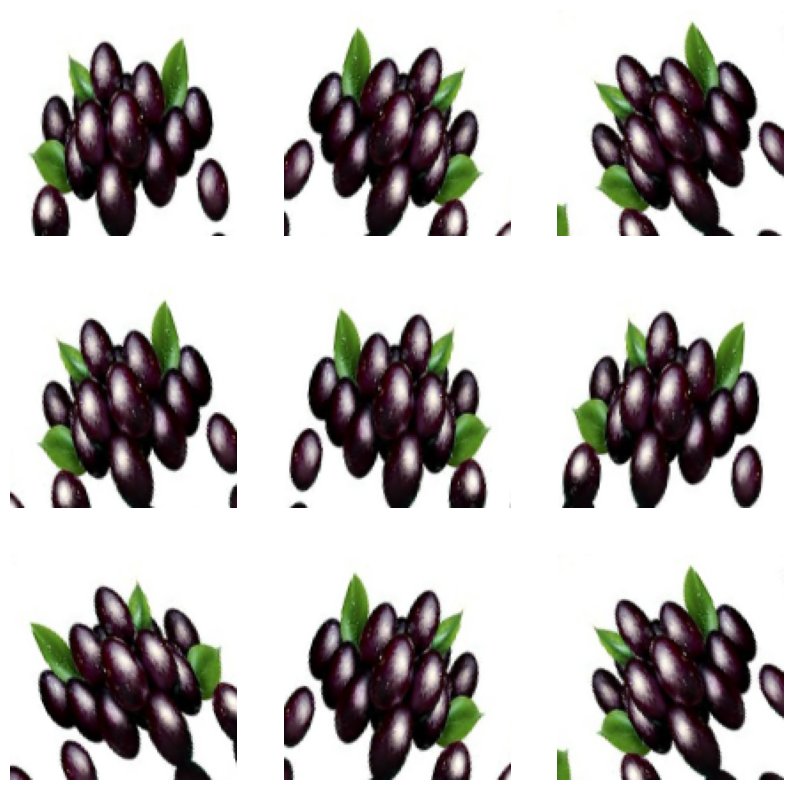

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(augmented_images[0]))
    plt.axis("off")

### Task 1: Improved Custom CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Lambda, Input, Rescaling
import os

# Re-extract class names and update num_classes
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

# Define the improved model following Section 2.3.1
model = Sequential([
    Input(shape=(128, 128, 3)),

    # Data augmentation applied using Lambda layer
    Lambda(data_augmentation),

    # Rescaling layer to normalize pixel values
    Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,799,814 (64.09 MB)

 Trainable params: 16,799,110 (64.08 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Re-initialize val_ds and early_stop
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 866ms/step - accuracy: 0.3056 - loss: 2.4436 - val_accuracy: 0.0000e+00 - val_loss: 1.8217
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4861 - loss: 1.3746 - val_accuracy: 0.0000e+00 - val_loss: 1.9586
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 825ms/step - accuracy: 0.6667 - loss: 0.9738 - val_accuracy: 0.0000e+00 - val_loss: 2.2448
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 764ms/step - accuracy: 0.6806 - loss: 0.9281 - val_accuracy: 0.0000e+00 - val_loss: 2.5724
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 972ms/step - accuracy: 0.6667 - loss: 0.9323 - val_accuracy: 0.0000e+00 - val_loss: 2.9106
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 856ms/step - accuracy: 0.6806 - loss: 0.6946 - val_accuracy: 0.0000e+00 - val_loss: 3.2486
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 956ms/step - accuracy: 0.7639 - loss: 0.6342 - val_accuracy: 0.0000e+00 - val_loss: 3.5265
Epoch 8/30
5/5 ━━━━━━━━

### Task 2: Transfer Learning with MobileNet

In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Ensure num_classes is defined
num_classes = len(class_names)

# 1. Load the Pre-trained Model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# 2. Freeze the Layers
for layer in base_model.layers:
    layer.trainable = False

# 3. Add Custom Layers
# Following Section 4 instructions
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions_vgg = Dense(num_classes, activation='softmax')(x)

# 4. Create the Final Model
transfer_model = Model(inputs=base_model.input, outputs=predictions_vgg)

# 5. Compile
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning Model initialized with VGG16 base.")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Transfer Learning Model initialized with VGG16 base.


In [ ]:
# Train the transfer learning model
vgg_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 496ms/step - accuracy: 0.4028 - loss: 1.9410 - val_accuracy: 0.8333 - val_loss: 0.6097
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.9028 - loss: 0.2851 - val_accuracy: 0.9444 - val_loss: 0.4366
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - accuracy: 0.9722 - loss: 0.1271 - val_accuracy: 0.8889 - val_loss: 0.3293
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.9861 - loss: 0.0262 - val_accuracy: 0.9444 - val_loss: 0.3904
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 1.0000 - loss: 0.0187 - val_accuracy: 0.9444 - val_loss: 0.5034
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.9722 - loss: 0.0680 - val_accuracy: 0.9444 - val_loss: 0.5284
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.8889 - val_loss: 0.6357
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.8889 - val_loss:

In [ ]:
# Fixed Classification Report for Task 2
y_true_vgg = []
y_pred_vgg = []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

# Identify which classes are actually present in the validation set
present_labels = np.unique(y_true_vgg)
present_names = [class_names[i] for i in present_labels]

print("VGG16 Transfer Learning Classification Report:")
print(classification_report(
    y_true_vgg,
    y_pred_vgg,
    labels=present_labels,
    target_names=present_names
))

VGG16 Transfer Learning Classification Report:
              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

   micro avg       0.94      0.89      0.91        18
   macro avg       0.97      0.80      0.87        18
weighted avg       0.94      0.89      0.91        18

